# SVD e aproximação de posto baixo

**Tema:** Álgebra Linear e Otimização › Decomposições: SVD, Autovalores e PCA

A SVD funciona para **qualquer** matriz, quadrada ou não. Este notebook
constrói a decomposição na mão, prova a conexão com autovalores de $X^\top X$,
e usa o teorema de Eckart-Young para comprimir uma imagem de verdade — a
demonstração mais visual de que "descartar os menores valores singulares" é
uma forma **ótima** de comprimir informação.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image

rng = np.random.default_rng(11)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. SVD de uma matriz pequena, na unha

`np.linalg.svd` devolve `U`, `s` (só a diagonal de Σ, como vetor) e `Vt`
(já transposta). Vamos reconstruir a matriz original e verificar cada peça.

In [2]:
X = np.array([[3.0, 2.0, 2.0],
              [2.0, 3.0, -2.0]])

U, s, Vt = np.linalg.svd(X, full_matrices=False)

print("U (vetores singulares à esquerda):\n", U)
print("\nvalores singulares:", s)
print("\nVt (vetores singulares à direita, transpostos):\n", Vt)

X_reconstruida = U @ np.diag(s) @ Vt
print("\nX original:\n", X)
print("\nX reconstruída U @ diag(s) @ Vt:\n", X_reconstruida)
print("\ndiferença máxima:", np.abs(X - X_reconstruida).max())

print(f"\nU é ortogonal?  {np.allclose(U.T @ U, np.eye(U.shape[1]))}")
print(f"V é ortogonal?  {np.allclose(Vt @ Vt.T, np.eye(Vt.shape[0]))}")

U (vetores singulares à esquerda):
 [[-0.7071 -0.7071]
 [-0.7071  0.7071]]

valores singulares: [5. 3.]

Vt (vetores singulares à direita, transpostos):
 [[-0.7071 -0.7071  0.    ]
 [-0.2357  0.2357 -0.9428]]

X original:
 [[ 3.  2.  2.]
 [ 2.  3. -2.]]

X reconstruída U @ diag(s) @ Vt:
 [[ 3.  2.  2.]
 [ 2.  3. -2.]]

diferença máxima: 8.881784197001252e-16

U é ortogonal?  True
V é ortogonal?  True


## 2. A ponte com autovalores: V vem de X^T X, U vem de X X^T

Isso é só para **entender** a relação — nunca calcule a SVD desse jeito na
prática (formar $X^\top X$ eleva o número de condição ao quadrado).

In [3]:
autoval_XtX, autovec_XtX = np.linalg.eigh(X.T @ X)
# eigh ordena crescente; a SVD ordena decrescente -> invertemos
ordem = np.argsort(autoval_XtX)[::-1]
autoval_XtX, autovec_XtX = autoval_XtX[ordem], autovec_XtX[:, ordem]

sigma_via_autovalores = np.sqrt(np.clip(autoval_XtX, 0, None))

print("valores singulares (SVD direta)         :", s)
print("valores singulares (sqrt autoval de XtX):", sigma_via_autovalores)
print("\nautovetores de X^T X (colunas):\n", autovec_XtX)
print("\nV^T da SVD direta:\n", Vt)
print("\n(sinais podem diferir por coluna — isso é esperado e inofensivo)")

valores singulares (SVD direta)         : [5. 3.]
valores singulares (sqrt autoval de XtX): [5. 3. 0.]

autovetores de X^T X (colunas):
 [[-0.7071  0.2357 -0.6667]
 [-0.7071 -0.2357  0.6667]
 [-0.      0.9428  0.3333]]

V^T da SVD direta:
 [[-0.7071 -0.7071  0.    ]
 [-0.2357  0.2357 -0.9428]]

(sinais podem diferir por coluna — isso é esperado e inofensivo)


## 3. Posto e valores singulares

O número de valores singulares **não-nulos** é o posto. Vamos construir uma
matriz deliberadamente deficiente em posto (uma coluna combinação linear das
outras) e ver isso na prática.

In [4]:
A_completa = rng.normal(size=(5, 4))
A_deficiente = A_completa.copy()
A_deficiente[:, 3] = 2 * A_deficiente[:, 0] - 0.5 * A_deficiente[:, 1]  # dependência exata

for nome, M in [("posto completo", A_completa), ("posto deficiente", A_deficiente)]:
    valores_sing = np.linalg.svd(M, compute_uv=False)
    posto_numpy = np.linalg.matrix_rank(M)
    print(f"{nome:<18s}  valores singulares = {np.round(valores_sing, 4)}"
          f"   posto = {posto_numpy}")

posto completo      valores singulares = [2.6556 2.0269 1.2471 0.278 ]   posto = 4
posto deficiente    valores singulares = [4.0973 1.988  1.5904 0.    ]   posto = 3


O último valor singular da matriz deficiente é (numericamente) zero — é
assim que `np.linalg.matrix_rank` de fato decide o posto por baixo dos panos:
conta quantos valores singulares superam um limiar de tolerância.

## 4. Compressão de imagem: Eckart-Young em ação

Uma imagem em tons de cinza é só uma matriz de números. Truncar a SVD nos $k$
maiores valores singulares produz a **melhor** aproximação de posto $k$
possível — não uma aproximação qualquer.

dimensão da imagem: (427, 640)   (posto máximo possível = 427)


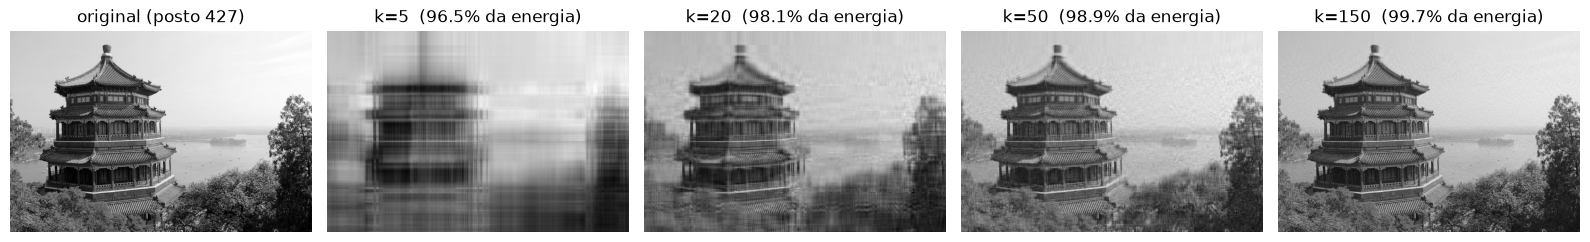

In [5]:
imagem_rgb = load_sample_image("china.jpg")
# tons de cinza: média ponderada dos 3 canais, forma padrão de "achatar" cor
imagem = (imagem_rgb @ np.array([0.299, 0.587, 0.114])).astype(float)
print(f"dimensão da imagem: {imagem.shape}   (posto máximo possível = "
      f"{min(imagem.shape)})")

U_img, s_img, Vt_img = np.linalg.svd(imagem, full_matrices=False)


def aproxima(k):
    return U_img[:, :k] @ np.diag(s_img[:k]) @ Vt_img[:k, :]


ks = [5, 20, 50, 150]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(16, 3.6))
axes[0].imshow(imagem, cmap="gray")
axes[0].set_title(f"original (posto {min(imagem.shape)})")
for ax, k in zip(axes[1:], ks):
    ax.imshow(aproxima(k), cmap="gray")
    energia = (s_img[:k] ** 2).sum() / (s_img ** 2).sum()
    ax.set_title(f"k={k}  ({energia:.1%} da energia)")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

Com $k=150$ (menos de 40% do posto máximo), a imagem já é visualmente quase
indistinguível da original. É esse fenômeno — poucos valores singulares
carregam a maior parte da "energia" — que torna a SVD uma ferramenta de
compressão eficiente, e não só uma curiosidade matemática.

## 5. Quanto custa, em espaço, cada aproximação

In [6]:
n, p = imagem.shape
custo_original = n * p
print(f"{'k':>5s} {'nº de floats armazenados':>26s} {'fração do original':>20s} "
      f"{'energia explicada':>19s}")
print("-" * 74)
for k in [5, 20, 50, 150, min(n, p)]:
    custo_k = k * (n + p + 1)  # U_k (n x k) + s_k (k) + Vt_k (k x p)
    energia = (s_img[:k] ** 2).sum() / (s_img ** 2).sum()
    print(f"{k:>5d} {custo_k:>26,d} {custo_k / custo_original:>19.1%} "
          f"{energia:>18.1%}")

    k   nº de floats armazenados   fração do original   energia explicada
--------------------------------------------------------------------------
    5                      5,340                2.0%              96.5%
   20                     21,360                7.8%              98.1%
   50                     53,400               19.5%              98.9%
  150                    160,200               58.6%              99.7%
  427                    456,036              166.9%             100.0%


**A troca explícita:** armazenar $U_k$, $\Sigma_k$ e $V_k^\top$ custa
$k(n+p+1)$ números em vez de $np$. Quando $k \ll \min(n,p)$, a economia é
grande — e, pelo teorema de Eckart-Young, essa é a melhor economia possível
para o erro que ela introduz.

## 6. O espectro de valores singulares: onde "cortar"

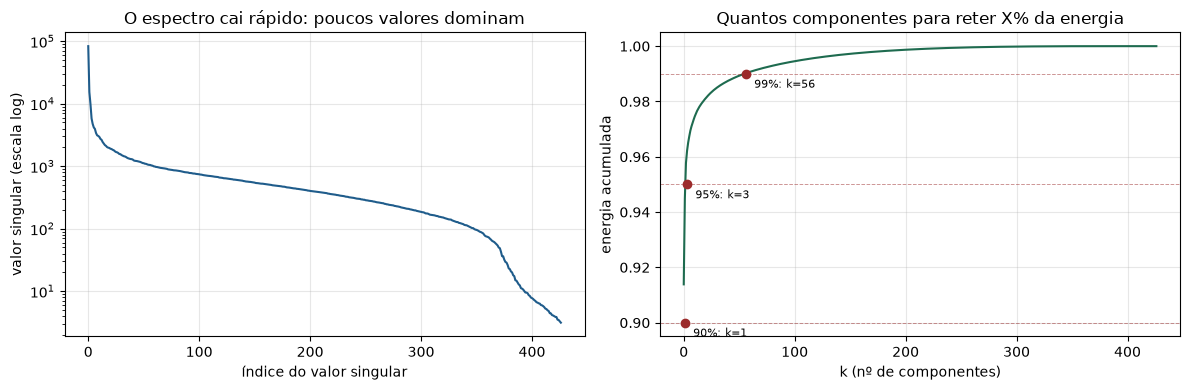

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s_img, color=AZUL, lw=1.5)
axes[0].set_yscale("log")
axes[0].set_xlabel("índice do valor singular"); axes[0].set_ylabel("valor singular (escala log)")
axes[0].set_title("O espectro cai rápido: poucos valores dominam")

energia_acumulada = np.cumsum(s_img ** 2) / np.sum(s_img ** 2)
axes[1].plot(energia_acumulada, color=VERDE, lw=1.5)
for alvo in [0.90, 0.95, 0.99]:
    k_necessario = np.searchsorted(energia_acumulada, alvo) + 1
    axes[1].axhline(alvo, color=VERMELHO, lw=0.7, ls="--", alpha=0.5)
    axes[1].scatter([k_necessario], [alvo], color=VERMELHO, zorder=3)
    axes[1].annotate(f"{alvo:.0%}: k={k_necessario}", (k_necessario, alvo),
                     textcoords="offset points", xytext=(6, -10), fontsize=8)
axes[1].set_xlabel("k (nº de componentes)"); axes[1].set_ylabel("energia acumulada")
axes[1].set_title("Quantos componentes para reter X% da energia")
plt.tight_layout(); plt.show()

## O que levar deste notebook

- A SVD decompõe **qualquer** matriz como rotação → esticamento → rotação, e
  se calcula de forma estável direto em $X$, nunca via $X^\top X$.
- O posto é o número de valores singulares não-nulos (na prática,
  "numericamente não-nulos").
- **Eckart-Young:** truncar a SVD nos $k$ maiores valores singulares é a
  melhor aproximação possível de posto $k$ — não uma entre várias boas, a
  ótima.
- O espectro de valores singulares geralmente cai rápido: poucos componentes
  carregam a maior parte da informação, o que torna a compressão útil na
  prática, não só na teoria.

→ Próximo: **PCA do zero**, aplicando exatamente essas ideias a dados
tabulares.